In [43]:
# Import packages
import pandas as pd
import numpy as np

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics

import seaborn as sns
sns.set(style = "darkgrid")

import matplotlib.pyplot as plt

import os

os.chdir('/PHI_conf/PrescribingBCS/Topics/Budgets/Phasings/Development/prescribing-forecast')
print("Current Working Directory:", os.getcwd())

Current Working Directory: /PHI_conf/PrescribingBCS/Topics/Budgets/Phasings/Development/prescribing-forecast


Now, we will read in the data required and filter for a board.

In [44]:
# Read in data and filter for NHS A&A
df = pd.read_csv("shiny/forecasts/data/Historical Data.csv", thousands=',')

filtered_df = df[df['Disp Health Board Name'] == 'NHS AYRSHIRE & ARRAN']

# Check filter has worked
filtered_df.head()

,Disp Health Board Name,Paid Date,Claim PD Number of Paid Items,Claim PD Paid GIC excl. BB
1,NHS AYRSHIRE & ARRAN,30/04/2009,544244,5937827.47
2,NHS AYRSHIRE & ARRAN,31/05/2009,534859,5844378.81
3,NHS AYRSHIRE & ARRAN,30/06/2009,562027,6126432.39
4,NHS AYRSHIRE & ARRAN,31/07/2009,582092,6401860.72
5,NHS AYRSHIRE & ARRAN,31/08/2009,533418,5891049.14


In [45]:
# Check column types
print(filtered_df.dtypes)

Disp Health Board Name               str
Paid Date                            str
Claim PD Number of Paid Items      int64
Claim PD Paid GIC excl. BB       float64
dtype: object


In [46]:
# Check for duplicate rows
duplicate_rows = filtered_df[filtered_df.duplicated()]
print("Number of duplicate rows:", duplicate_rows.shape)

Number of duplicate rows: (0, 4)


In [47]:
# Summary statistics
print(filtered_df.describe())

       Claim PD Number of Paid Items  Claim PD Paid GIC excl. BB
count                     201.000000                2.010000e+02
mean                   668862.985075                6.503802e+06
std                     70710.705469                6.040040e+05
min                    512807.000000                5.300322e+06
25%                    621459.000000                6.070684e+06
50%                    664148.000000                6.433122e+06
75%                    712830.000000                6.907107e+06
max                    863612.000000                8.086921e+06


In [48]:
# Count number of null values in each column
print(filtered_df.isnull().sum())

Disp Health Board Name           0
Paid Date                        0
Claim PD Number of Paid Items    0
Claim PD Paid GIC excl. BB       0
dtype: int64


We now have to create lagged values along with some rolling averages to allow for further input variables to be incorporated.

In [49]:
# Remove board column and index by date
dt_df = filtered_df.drop(['Disp Health Board Name', 'Claim PD Paid GIC excl. BB'], axis = 1)

dt_df['Paid Date'] = pd.to_datetime(dt_df['Paid Date'], errors='coerce')

dt_df.set_index('Paid Date', inplace = True)

# 3. Ensure the index is sorted (important for time series operations)
dt_df.sort_index(inplace=True)

print(dt_df)
print("\nIndex type:", type(dt_df.index))

print(dt_df.dtypes)

            Claim PD Number of Paid Items
Paid Date                                
2009-04-30                         544244
2009-05-31                         534859
2009-06-30                         562027
2009-07-31                         582092
2009-08-31                         533418
...                                   ...
2025-08-31                         763732
2025-09-30                         777075
2025-10-31                         810081
2025-11-30                         736312
2025-12-31                         863612

[201 rows x 1 columns]

Index type: <class 'pandas.DatetimeIndex'>
Claim PD Number of Paid Items    int64
dtype: object


/tmp/ipykernel_1118/2697410879.py:4: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  dt_df['Paid Date'] = pd.to_datetime(dt_df['Paid Date'], errors='coerce')


In [50]:
def make_lagged_df_with_rolling(series, lags=12, roll_window=3):
    df = series
    
    for lag in range(1, lags+1):
        df[f"lag_{lag}"] = df["Claim PD Number of Paid Items"].shift(lag)
    
    df[f"roll_mean_{roll_window}"] = df["Claim PD Number of Paid Items"].shift(1).rolling(roll_window).mean()
    df[f"roll_std_{roll_window}"] = df["Claim PD Number of Paid Items"].shift(1).rolling(roll_window).std()
    
    return df.dropna()

lagged_df = make_lagged_df_with_rolling(dt_df, lags=12, roll_window=3)
lagged_df.head()

,Claim PD Number of Paid Items,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,roll_mean_3,roll_std_3
Paid Date,,,,,,,,,,,,,,,
2010-04-30,566592,591189.0,512807.0,520856.0,610563.0,529570.0,576149.0,549080.0,533418.0,582092.0,562027.0,534859.0,544244.0,541617.333333,43118.548240
2010-05-31,545576,566592.0,591189.0,512807.0,520856.0,610563.0,529570.0,576149.0,549080.0,533418.0,582092.0,562027.0,534859.0,556862.666667,40086.524249
2010-06-30,588362,545576.0,566592.0,591189.0,512807.0,520856.0,610563.0,529570.0,576149.0,549080.0,533418.0,582092.0,562027.0,567785.666667,22829.916170
2010-07-31,572742,588362.0,545576.0,566592.0,591189.0,512807.0,520856.0,610563.0,529570.0,576149.0,549080.0,533418.0,582092.0,566843.333333,21394.107257
2010-08-31,559863,572742.0,588362.0,545576.0,566592.0,591189.0,512807.0,520856.0,610563.0,529570.0,576149.0,549080.0,533418.0,568893.333333,21651.088318


Now let's find correlations between the numerical values with a heatmap.

                               Claim PD Number of Paid Items     lag_1  \
Claim PD Number of Paid Items                       1.000000  0.747002   
lag_1                                               0.747002  1.000000   
lag_2                                               0.792590  0.752168   
lag_3                                               0.847185  0.788356   
lag_4                                               0.774551  0.847763   
lag_5                                               0.845454  0.775872   
lag_6                                               0.794343  0.841837   
lag_7                                               0.823175  0.797150   
lag_8                                               0.802784  0.820929   
lag_9                                               0.837125  0.801076   
lag_10                                              0.750528  0.838881   
lag_11                                              0.782700  0.757672   
lag_12                                

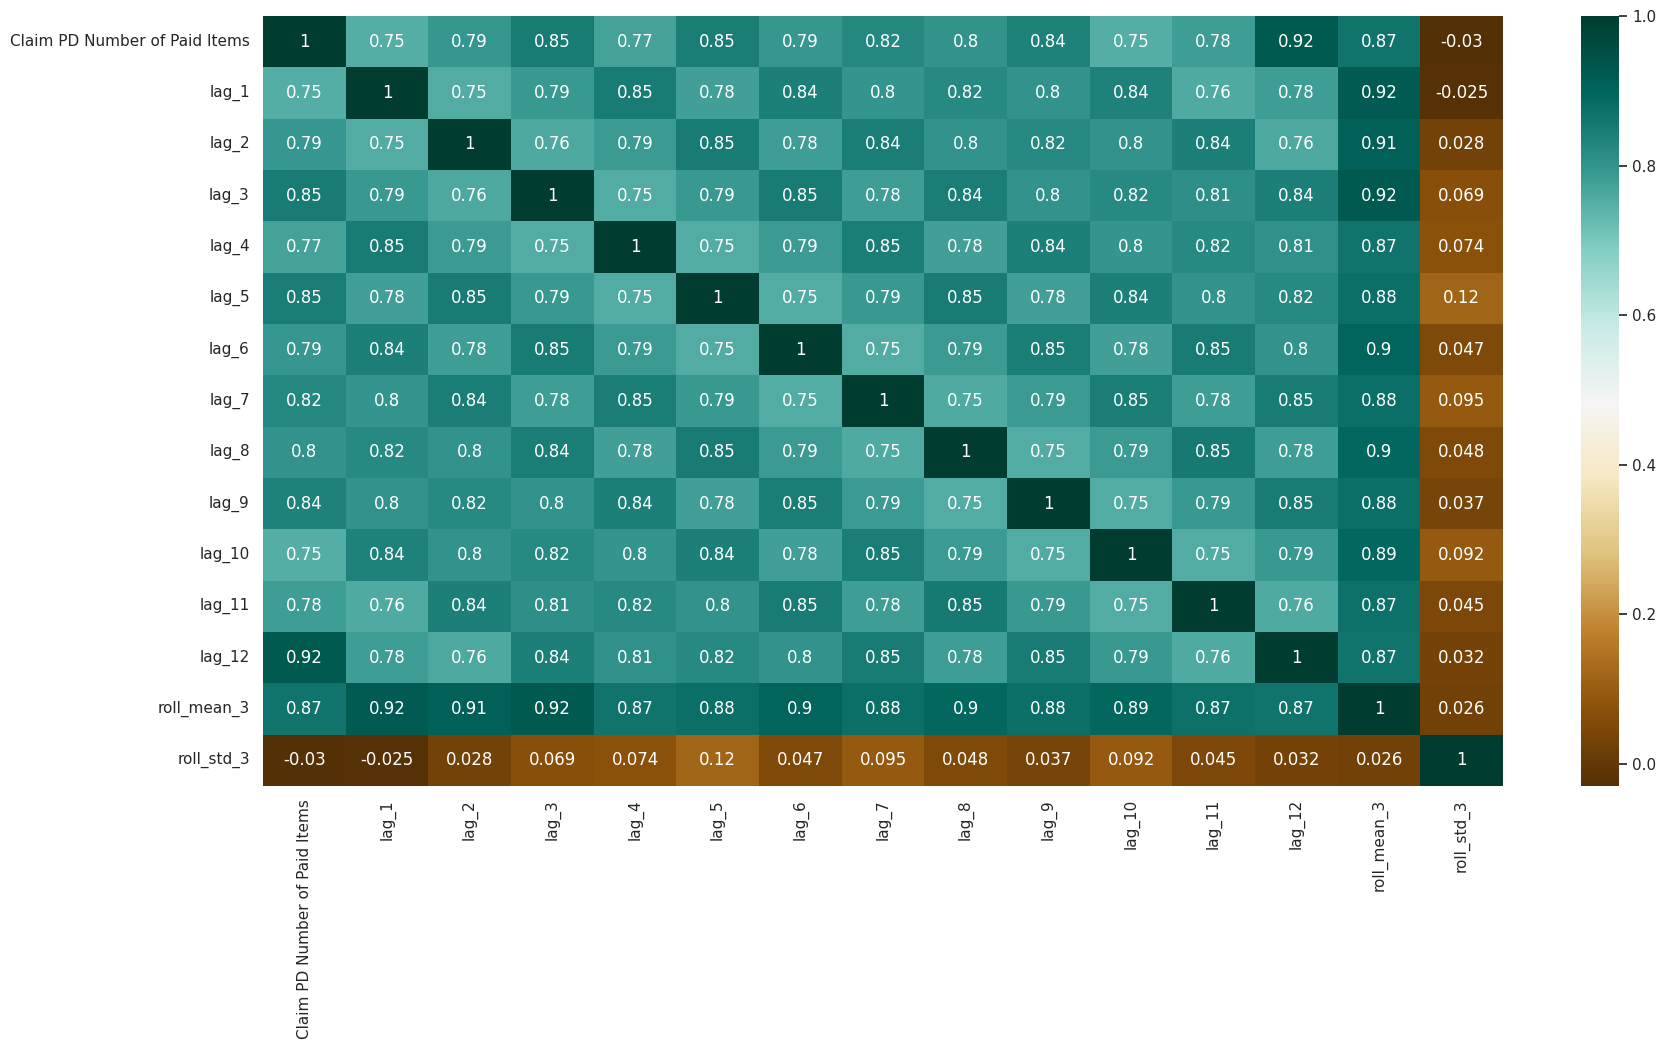

In [51]:
plt.figure(figsize=(20,10))
corl = lagged_df.corr()

sns.heatmap(corl, cmap = "BrBG", annot = True)
print(corl)

Let's now prepare the data for model fitting.

In [52]:
# Split dataset into input variable X and target variable Y
X = lagged_df.drop(['Claim PD Number of Paid Items'], axis = 1)

# Check if been removed
X.head()

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,roll_mean_3,roll_std_3
Paid Date,,,,,,,,,,,,,,
2010-04-30,591189.0,512807.0,520856.0,610563.0,529570.0,576149.0,549080.0,533418.0,582092.0,562027.0,534859.0,544244.0,541617.333333,43118.548240
2010-05-31,566592.0,591189.0,512807.0,520856.0,610563.0,529570.0,576149.0,549080.0,533418.0,582092.0,562027.0,534859.0,556862.666667,40086.524249
2010-06-30,545576.0,566592.0,591189.0,512807.0,520856.0,610563.0,529570.0,576149.0,549080.0,533418.0,582092.0,562027.0,567785.666667,22829.916170
2010-07-31,588362.0,545576.0,566592.0,591189.0,512807.0,520856.0,610563.0,529570.0,576149.0,549080.0,533418.0,582092.0,566843.333333,21394.107257
2010-08-31,572742.0,588362.0,545576.0,566592.0,591189.0,512807.0,520856.0,610563.0,529570.0,576149.0,549080.0,533418.0,568893.333333,21651.088318


In [53]:
# separate number of paid items
y = lagged_df['Claim PD Number of Paid Items']

# view target values
print(y[0:5])

Paid Date
2010-04-30    566592
2010-05-31    545576
2010-06-30    588362
2010-07-31    572742
2010-08-31    559863
Name: Claim PD Number of Paid Items, dtype: int64


We can now split the data into training and testing sets.

In [54]:

X = X.sort_index()
y = y.loc[X.index]        # <- ensure y aligns with X after sorting


X_train, X_Vali_test, y_train, y_Vali_test = train_test_split(X, y, test_size = 0.15, random_state = 1, shuffle = False)

print(X_train.shape)

(160, 14)


We can then construct a decision tree from this.

In [55]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

dt_reg = DecisionTreeRegressor()
dt_reg.fit(X_train, y_train)
y_pred = dt_reg.predict(X_Vali_test)

print("Forecasting:")
print("MAE:", mean_absolute_error(y_Vali_test, y_pred))
print("MSE:", mean_squared_error(y_Vali_test, y_pred))
print("RMSE:", root_mean_squared_error(y_Vali_test, y_pred))

Forecasting:
MAE: 23957.344827586207
MSE: 972908344.6551725
RMSE: 31191.4787186368


In [56]:

results = pd.DataFrame({
    "Actual": y_Vali_test,
    "Predicted": y_pred
})

print(results.head())

            Actual  Predicted
Paid Date                    
2023-08-31  780457   785906.0
2023-09-30  713999   751020.0
2023-10-31  759671   751020.0
2023-11-30  771247   751020.0
2023-12-31  777091   785906.0
